In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [5]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [6]:
df.shape

(48895, 16)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

**EDA**

In [13]:
#The missing value greater than Zero
#We will handel the Missing Value usind simpleimputer lateron
missing=df.isnull().sum()
missing[missing>0]

,0
name,16
host_name,21
last_review,10052
reviews_per_month,10052


**Target Variable —> Room type**

<Axes: xlabel='room_type', ylabel='count'>

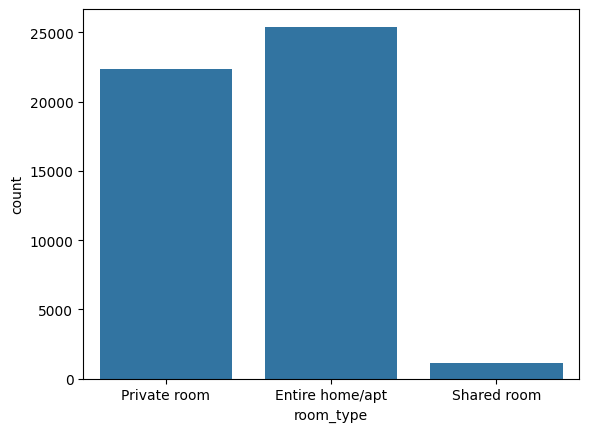

In [16]:
sns.countplot(x=df['room_type'])
#The shared room contribute less so it create problem in the training time of model we should handle during making pipeline.

**Univariate Analysis — Numeric Features**

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

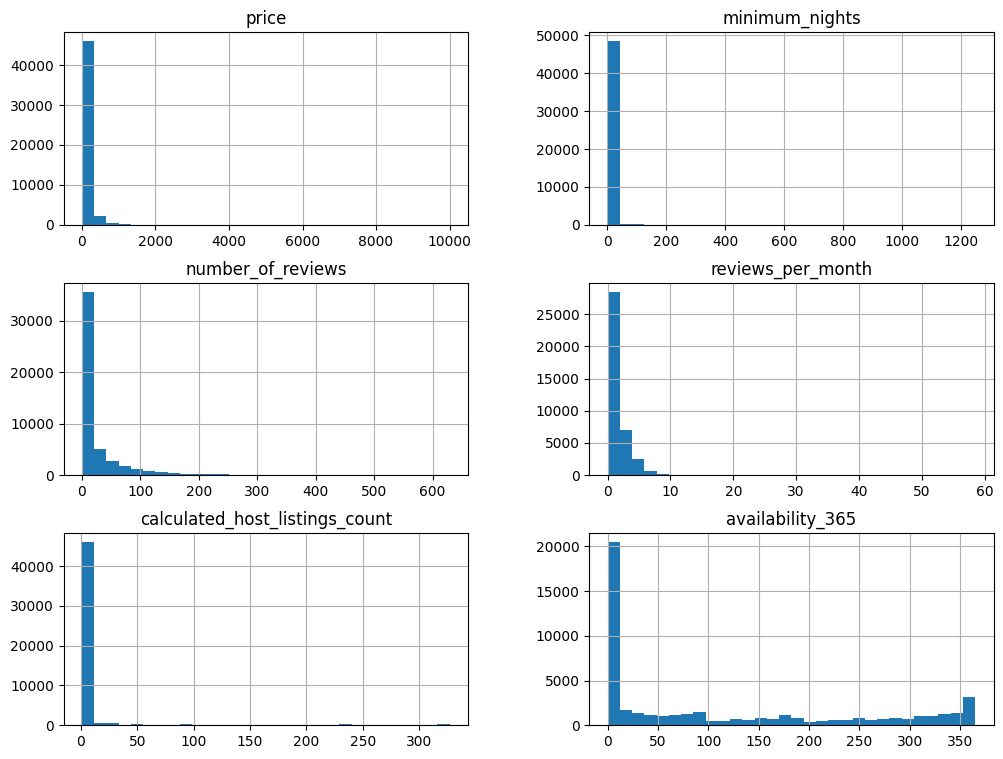

In [17]:
numerical_cols = ['price',"minimum_nights", "number_of_reviews",
                 "reviews_per_month", "calculated_host_listings_count",
                 "availability_365"] #Here we dont include the 'id', 'name', 'host_id' because they are unwanted Row
df[numerical_cols].hist(bins=30,figsize=(12,9))

**Univariate Analysis — Categorical Features**

<Axes: xlabel='neighbourhood_group', ylabel='count'>

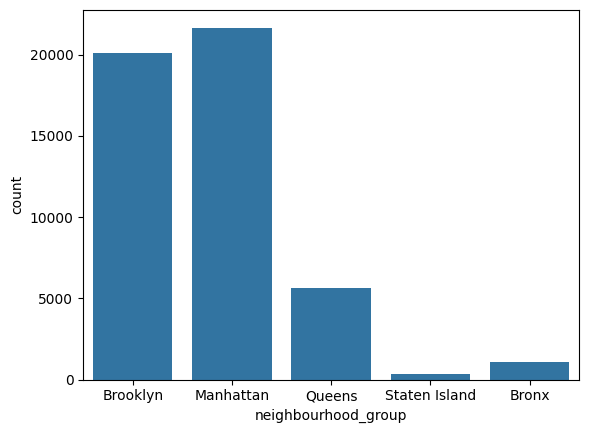

In [18]:
sns.countplot(x=df['neighbourhood_group'])

**Bivariate Analysis — Features vs Target**

<Axes: xlabel='room_type', ylabel='price'>

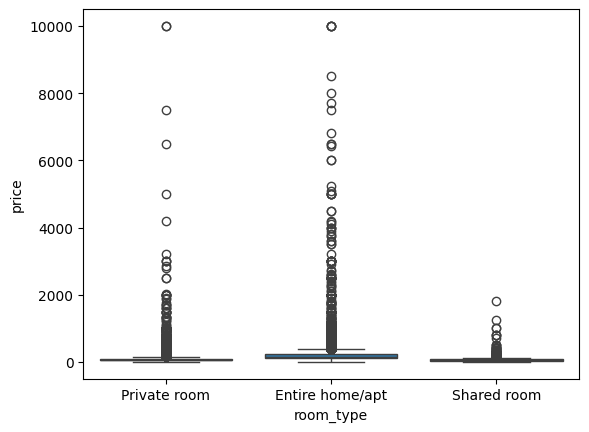

In [20]:
sns.boxplot(x=df['room_type'],y=df['price'])
#Here we got outliers but we will handle it in process of making pipeline

**Correlation Between Numeric Features**

<Axes: >

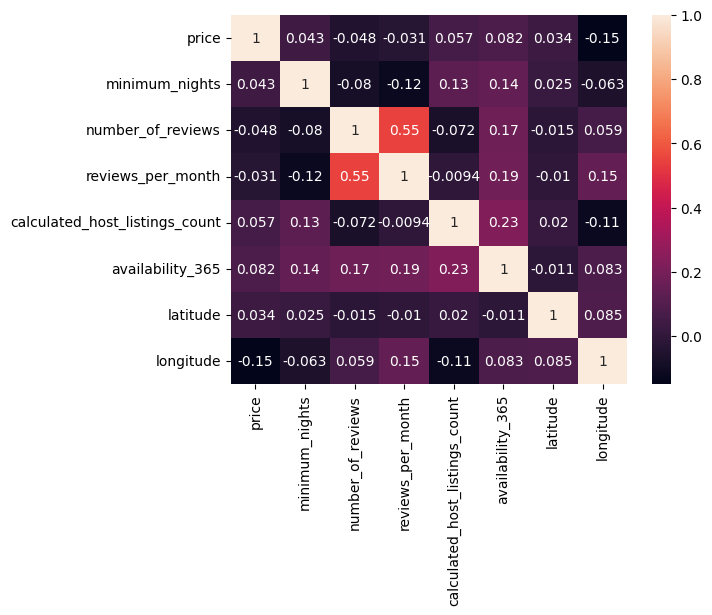

In [21]:
corr = df[numerical_cols+['latitude','longitude']].corr()
sns.heatmap(corr,annot=True)

**Geographic Distribution (Bonus Visual)**

<Axes: xlabel='longitude', ylabel='latitude'>

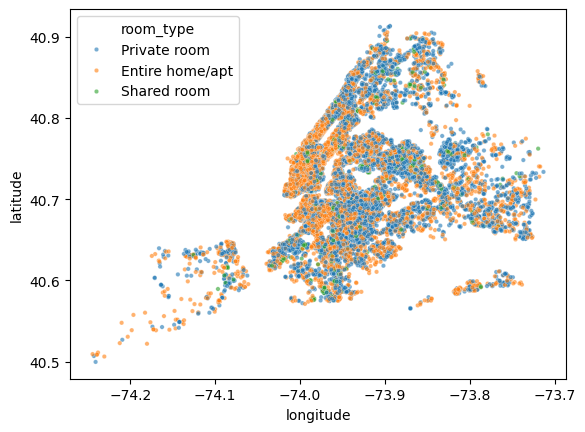

In [25]:
sns.scatterplot(x=df['longitude'],y=df['latitude'],hue=df['room_type'],alpha=0.6,s=10)

**Data Cleaning & Feature Engineering**

In [27]:
#Drop Columns that dont help us
df_clean = df.drop(columns=['id', 'name', 'host_id','last_review','host_name'])
# No reviews yet -> 0 reviews per month, not missing
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

In [28]:
#There is outliers in the dateset time to handel that oultiers
#Cap Extreme outliers instead of deleting rows.
price_cap = df_clean['price'].quantile(0.99)
night_cap = df_clean['minimum_nights'].quantile(0.99)
df_clean['price']= df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper=night_cap)
# df_clean = df_clean[df_clean['price'] < price_cap]
# df_clean = df_clean[df_clean['minimum_nights'] < nights_cap]
#This remove all the upper bound outliers from the data

In [29]:
X = df_clean.drop(columns=['room_type'])
y= df_clean['room_type']

**Train / Test Split**:

We hold out 20% of the data as a test set that is never touched during model selection or tuning — it is only used once, at the very end, to report the final, honest performance. stratify=y keeps the same class proportions in both splits, which matters because the target is imbalanced.

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.33,random_state=42,stratify=y)
#we only use the stratify=y in classification model not in other

**Preprocessing: ColumnTransformer + Pipeline**

In [31]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer

In [33]:
numerical_cols = ['price',"minimum_nights", "number_of_reviews",
                 "reviews_per_month", "calculated_host_listings_count",
                 "availability_365",'latitude','longitude']
categorical_cols = ['neighbourhood_group','neighbourhood']
#Create pipeline for Numerical columns
numberic_pipeline = Pipeline(steps=[
    ('imput',SimpleImputer(strategy='median')),
    ('scale',StandardScaler())
])
# Categorical Pipeline
categorical_Pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="most_frequent")),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(transformers=[
    ("numerical", numberic_pipeline, numerical_cols),
    ("categorical", categorical_Pipeline, categorical_cols )
])
preprocessor


ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('imput',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['price', 'minimum_nights',
                                  'number_of_reviews', 'reviews_per_month',
                                  'calculated_host_listings_count',
                                  'availability_365', 'latitude',
                                  'longitude']),
                                ('categorical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encode',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['neighbourhood_group', 'neighbourhood'])])

In [34]:
df_clean['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

 **Trying Multiple Algorithms**

We now compare several models, each wrapped in its own pipeline with the same preprocessor. We evaluate each with 3-fold stratified cross-validation on the training set (never touching the test set yet), so the comparison is fair and robust.

Models tried:

Logistic Regression — simple, interpretable linear baseline

Decision Tree — a single non-linear model, prone to overfitting

Random Forest — an ensemble of trees, usually a strong general-purpose model

Gradient Boosting — sequential ensemble, often the most accurate of the classics

**SMOTE (Synthetic Minority Oversampling).**
for class Imbalance

1.High chances of Overfitting.

2.Data Leakage

In [35]:
import warnings
warnings.filterwarnings('ignore')

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

In [37]:
# class_weight="Balanced" tells the model to pay more attention to the minority class
# or rare class (Shared Room)
# but the problem is GradintBossting doesnt support class weight so we left it as it is.

models = {
    "Logistic Regression" : LogisticRegression(class_weight="balanced",random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(class_weight="balanced",random_state=42),
    "Random Forest"       : RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting"   : GradientBoostingClassifier(random_state=42), #No pram named class_weight so it is not a best model
}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])

    # Accuracy alone can be misleading on imbalanced classes, so we use macro f1
    # both: plain accuracy and macro f1 (which treats every class equally)

    accuracy = cross_val_score(pipe, X_train, y_train,cv=3,scoring="accuracy")
    macrof1 = cross_val_score(pipe, X_train, y_train,cv=3,scoring="f1_macro")

    print(f"{name} -> Accuracy: {accuracy.mean():.3f} , F1: {macrof1.mean():.3f}")

Logistic Regression -> Accuracy: 0.659 , F1: 0.522
Decision Tree -> Accuracy: 0.783 , F1: 0.647
Random Forest -> Accuracy: 0.848 , F1: 0.713
Gradient Boosting -> Accuracy: 0.850 , F1: 0.705


 **Hyperparameter Tuning**

In [38]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(class_weight='balanced'))
])

param_distribution = {
    "classifier__n_estimators" : [100,200,150,300],
    "classifier__max_depth": [8, 12, 15, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
}

search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_distribution,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    random_state=42
    )

search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numerical',
                                                                               Pipeline(steps=[('imput',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['price',
                                                                                'minimum_nights',
                                                                                'number_of_reviews',
                                                                                'reviews_per_month',
                                                                                'calculated_host_listings_count',
                                                                                'availability_365',
                                                                                'latitude',
                                                                                'longitude']),
                                                                              ('catego...
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encode',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['neighbourhood_group',
                                                                                'neighbourhood'])])),
                                             ('classifier',
                                              RandomForestClassifier(class_weight='balanced'))]),
                   param_distributions={'classifier__max_depth': [8, 12, 15, 20,
                                                                  None],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     150,
                                                                     300]},
                   random_state=42, scoring='f1_macro')

In [39]:
print("Best Parameters: ", search.best_params_)
print("Best CV Macro-F1: ", search.best_score_)


Best Parameters:  {'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__max_depth': None}
Best CV Macro-F1:  0.7304189369576389


In [40]:
import joblib

joblib.dump(best_pipeline, "Model_Pipeline.pkl",compress=3)

['Model_Pipeline.pkl']